# VGG Architecture Experiment

## 1. Introduction

VGG is a CNN architecture built around a simple idea: use small 3×3 convolutional filters and stack them to build deeper networks.

As the network goes deeper, it learns more complex features. The spatial size of the feature maps is reduced between blocks, while the number of channels increases.

In this project, I am using VGG to study how different architectural choices affect image classification on the Stanford Cars dataset.

The main things I want to study are:

- **Depth** — how changing the number of VGG blocks affects the model.
- **Width** — how changing the number of channels affects the model.
- **Batch Normalization** — how adding BatchNorm changes the learning behavior of the same architecture.

### VGG Block

A VGG block in this project contains:

- Three 3×3 convolutional layers
- ReLU activation after each convolution

The block therefore follows:

**Conv → ReLU → Conv → ReLU → Conv → ReLU**

The pooling layer is kept **outside the block**. This allows the number of convolutional layers in a block and the downsampling operation to be controlled separately.

After the VGG blocks, the feature maps are passed through the classification head and the final layer produces predictions for the 196 car classes.

The goal of the experiments is not just to get a high accuracy. I want to understand how changing the structure of the network affects how the model learns and performs.

## Experiment 1: Studying the Effect of Depth

The first experiment focuses on the **depth of the VGG network**.

Here, I will change the number of VGG blocks while keeping the other main architectural settings controlled. The goal is to see how adding more convolutional blocks affects the way the model learns and performs on the Stanford Cars classification task.

The base VGG architecture uses four blocks. From this base, I will compare models with different numbers of blocks while keeping the final feature representation and classification head consistent.

This experiment will help me understand whether making the network deeper changes its learning behavior, and how the added depth affects training and validation performance.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CNN_Architecture_Study

/content/drive/MyDrive/CNN_Architecture_Study


In [3]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from collections import OrderedDict
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
import cnn_utils

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# create VGG Block class

class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [6]:
# Baseline Architecture

class Baseline(nn.Module):

    def __init__(self):
      super().__init__()

      self.net = nn.Sequential(
          VGGBlock(3, 64),
          nn.MaxPool2d(2, 2),

          VGGBlock(64, 128),
          nn.MaxPool2d(2, 2),

          VGGBlock(128, 256),
          nn.MaxPool2d(2, 2),

          VGGBlock(256, 512),

          nn.AdaptiveAvgPool2d((1,1)),
          nn.Flatten(),
          nn.Linear(512, 196)
      )

    def forward(self, x):
      return self.net(x)
#

In [7]:
import cnn_utils

cnn_utils.set_seed(42)

In [8]:
data_path = "/content/drive/MyDrive/CNN_Architecture_Study/data/stanford_cars"

cars = cnn_utils.load_dataset(data_path)

Dataset loaded successfully.
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 8144
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
})


In [9]:
train_dataset, val_dataset, test_dataset = cnn_utils.prepare_datasets(
    cars,
    val_ratio=0.2,
    seed=42
)

In [10]:
train_transform, eval_transform = cnn_utils.create_transforms(
    image_size=(224, 224)
)

In [11]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    train_transform,
    eval_transform,
    batch_size=64,
    num_workers=2
)

In [12]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Labels min:", labels.min().item())
print("Labels max:", labels.max().item())

print("Unique labels:", torch.unique(labels))

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -2.1179039478302
Image max: 2.640000104904175
Labels min: 1
Labels max: 194
Unique labels: tensor([  1,   6,  13,  35,  37,  38,  43,  50,  52,  54,  56,  63,  64,  65,
         67,  74,  82,  84,  87,  88,  92,  96, 101, 102, 104, 105, 106, 109,
        110, 111, 113, 115, 118, 122, 126, 128, 131, 132, 139, 141, 145, 146,
        148, 151, 160, 165, 178, 180, 185, 191, 193, 194])


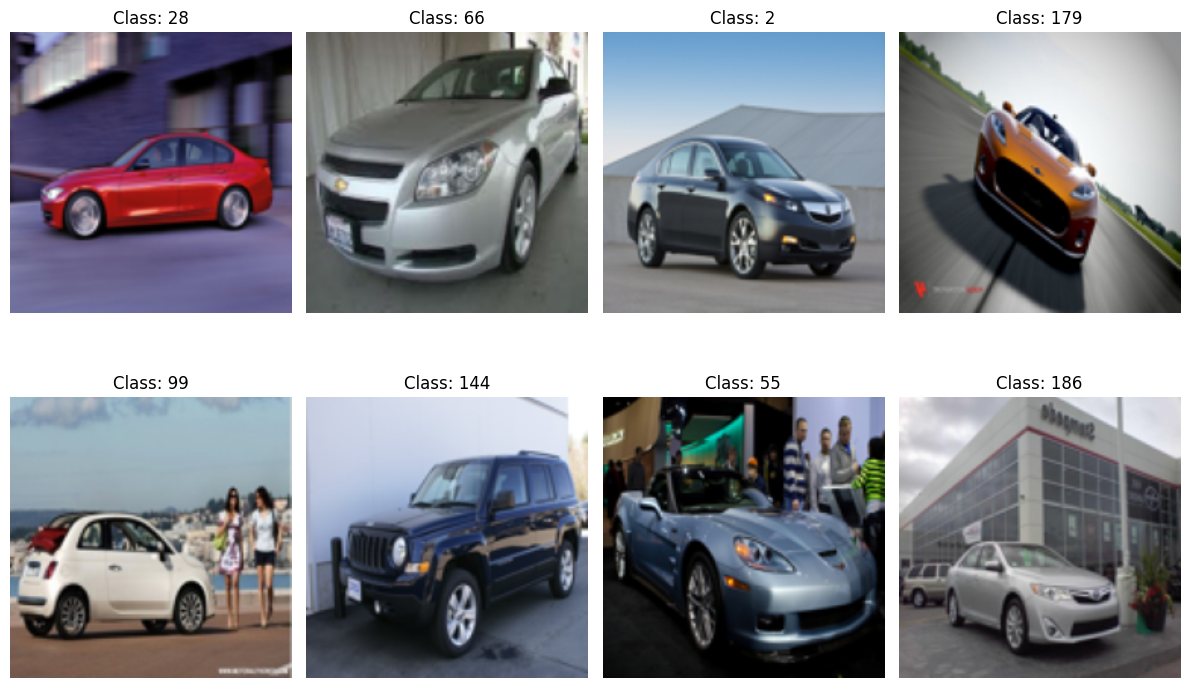

In [13]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(12, 8))

for i in range(8):
    image = images[i].cpu() * std + mean
    image = image.permute(1, 2, 0).clamp(0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def initialize_weights(model):

    for layer in model.modules():

        if isinstance(layer, nn.Conv2d):
            nn.init.kaiming_normal_(
                layer.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)

        elif isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)

            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)

In [17]:
baseline_model = Baseline()

In [18]:
initialize_weights(baseline_model)

In [19]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

In [20]:
!git status


Refresh index: 100% (3/3), done.
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   cnn_utils.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add .
!git commit -m ""
!git push -u origin main

In [ ]:
baseline_model, baseline_history = cnn_utils.train_model(
    baseline_model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    num_epochs=10,
    device=device
)